In [ ]:
# Decision Tree CART Example on IRIS Data set

In [3]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

In [2]:
help(DecisionTreeClassifier)

Help on class DecisionTreeClassifier in module sklearn.tree._classes:

class DecisionTreeClassifier(sklearn.base.ClassifierMixin, BaseDecisionTree)
 |  DecisionTreeClassifier(*, criterion='gini', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, class_weight=None, ccp_alpha=0.0, monotonic_cst=None)
 |
 |  A decision tree classifier.
 |
 |  Read more in the :ref:`User Guide <tree>`.
 |
 |  Parameters
 |  ----------
 |  criterion : {"gini", "entropy", "log_loss"}, default="gini"
 |      The function to measure the quality of a split. Supported criteria are
 |      "gini" for the Gini impurity and "log_loss" and "entropy" both for the
 |      Shannon information gain, see :ref:`tree_mathematical_formulation`.
 |
 |  splitter : {"best", "random"}, default="best"
 |      The strategy used to choose the split at each node. Supported
 |      strategies ar

In [4]:
print("=" * 60)
print("CART DECISION TREE EXPLANATION")
print("=" * 60)

CART DECISION TREE EXPLANATION


In [5]:
# Load the Iris dataset
print("\n1. Loading Iris Dataset...")
iris = load_iris()
X = iris.data
y = iris.target


1. Loading Iris Dataset...


In [6]:
# Create a DataFrame for better visualization
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(y, iris.target_names)


In [7]:
print("\nDataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nClass distribution:")
print(df['species'].value_counts())


Dataset shape: (150, 5)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [8]:
print("\n2. Splitting data into training (70%) and testing (30%) sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


2. Splitting data into training (70%) and testing (30%) sets...


In [9]:
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

# Create and train CART Decision Tree
print("\n3. Training CART Decision Tree Classifier...")
print("\nCART Algorithm works by:")
print("  - Recursively splitting data based on feature values")
print("  - Using Gini impurity as the splitting criterion")
print("  - Creating binary splits (yes/no decisions)")
print("  - Stopping when a stopping criterion is met")

Training samples: 105, Testing samples: 45

3. Training CART Decision Tree Classifier...

CART Algorithm works by:
  - Recursively splitting data based on feature values
  - Using Gini impurity as the splitting criterion
  - Creating binary splits (yes/no decisions)
  - Stopping when a stopping criterion is met


In [10]:
clf = DecisionTreeClassifier(
    criterion='gini',      # CART uses Gini impurity
    max_depth=3,           # Limit depth to avoid overfitting
    min_samples_split=2,   # Minimum samples to split a node
    random_state=42
)



Tree depth: 3
Number of leaves: 5

4. Making predictions on test set...

5. Model Evaluation:

Accuracy: 0.9778 (97.78%)

Confusion Matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  0 15]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.93      0.97        15
   virginica       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45


6. Feature Importance:
             feature  importance
2  petal length (cm)    0.550877
3   petal width (cm)    0.449123
1   sepal width (cm)    0.000000
0  sepal length (cm)    0.000000

7. Visualizing the Decision Tree...
Tree visualization saved as 'decision_tree.png'


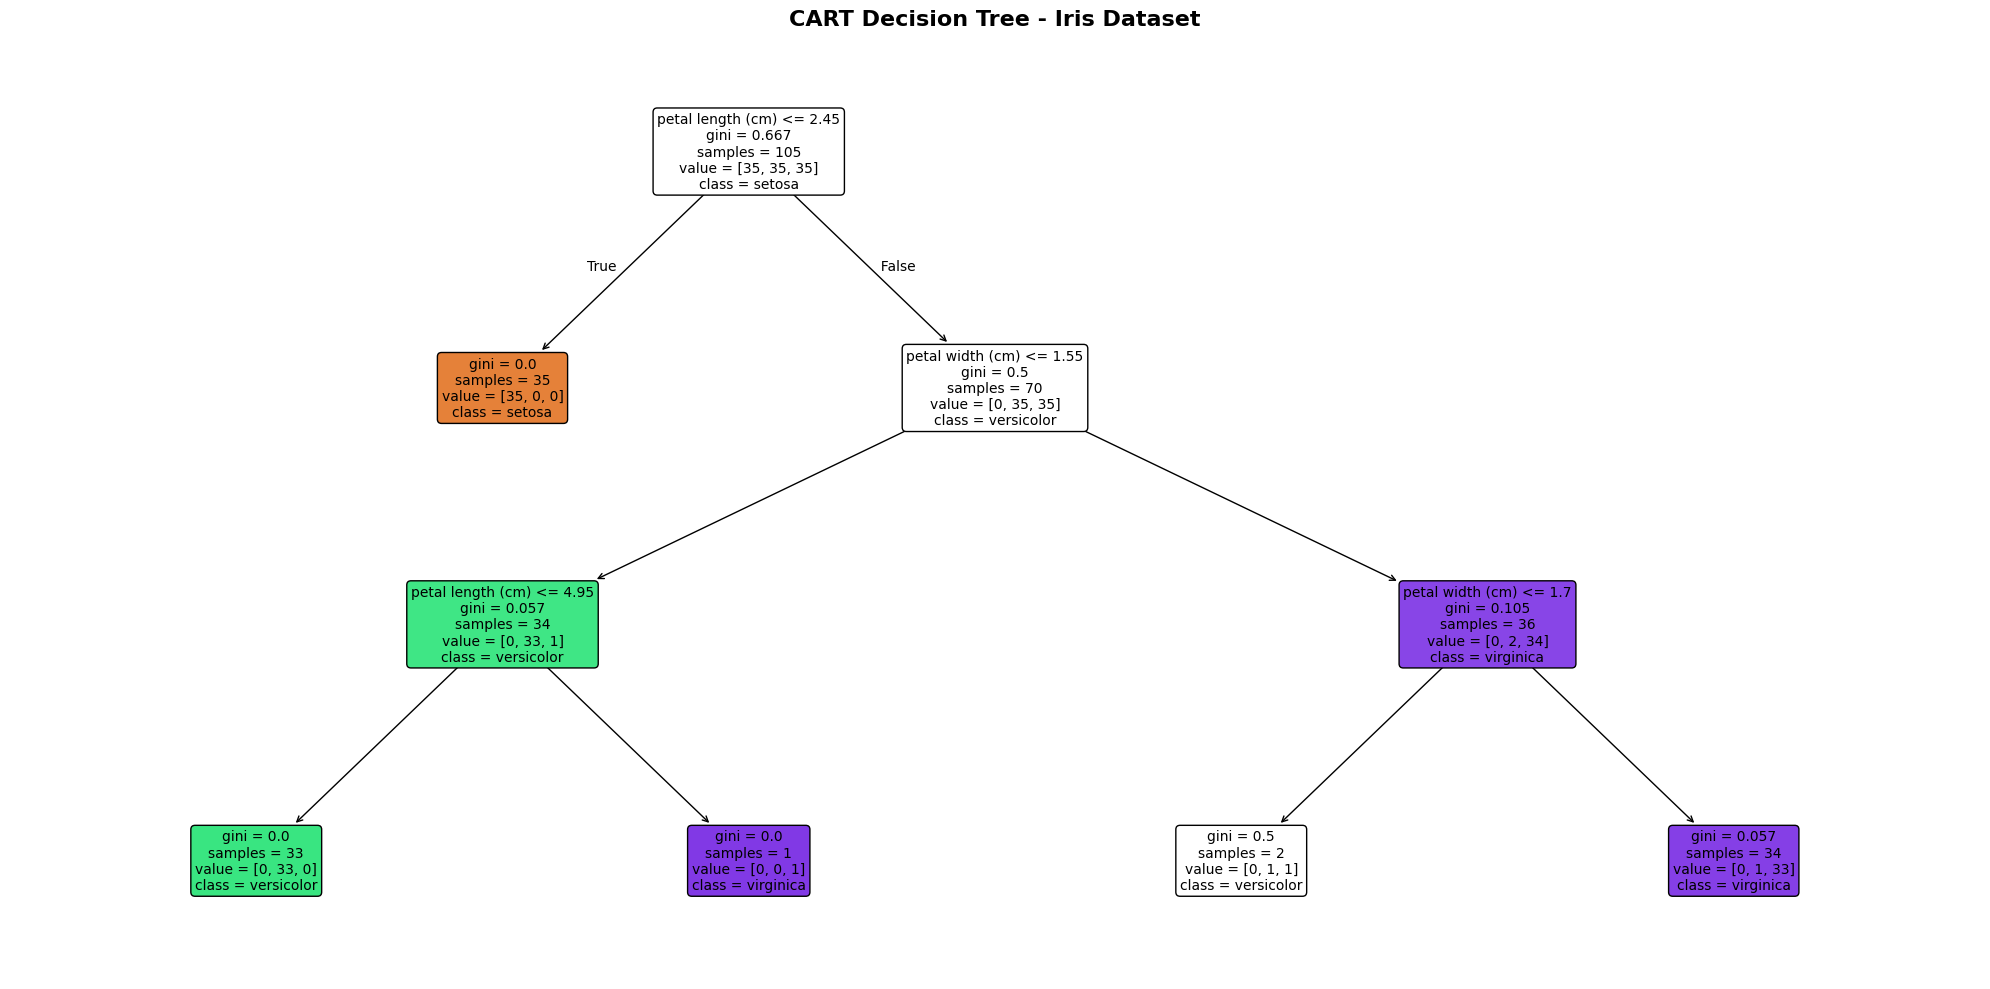


8. Example Prediction:

Sample features: [7.3 2.9 6.3 1.8]
Predicted class: virginica
Actual class: virginica

Class probabilities:
  setosa: 0.0000
  versicolor: 0.0294
  virginica: 0.9706

KEY CONCEPTS OF CART DECISION TREES

1. GINI IMPURITY: Measures node impurity (0 = pure, 0.5 = max impurity)
   Formula: Gini = 1 - Σ(pi²) where pi is probability of class i

2. SPLITTING: At each node, algorithm finds the best feature and 
   threshold that minimizes weighted Gini impurity of child nodes

3. BINARY TREE: Each internal node has exactly two children (yes/no)

4. STOPPING CRITERIA: Tree stops growing when:
   - Maximum depth is reached
   - Minimum samples per node is reached
   - Node is pure (all samples belong to one class)

5. PREDICTION: Follow decision path from root to leaf based on 
   feature values, return majority class in the leaf node



In [11]:
clf.fit(X_train, y_train)
print("\nTree depth:", clf.get_depth())
print("Number of leaves:", clf.get_n_leaves())

# Make predictions
print("\n4. Making predictions on test set...")
y_pred = clf.predict(X_test)

# Evaluate the model
print("\n5. Model Evaluation:")
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Feature importance
print("\n6. Feature Importance:")
feature_importance = pd.DataFrame({
    'feature': iris.feature_names,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance)

# Visualize the tree
print("\n7. Visualizing the Decision Tree...")
plt.figure(figsize=(20, 10))
plot_tree(clf,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("CART Decision Tree - Iris Dataset", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=300, bbox_inches='tight')
print("Tree visualization saved as 'decision_tree.png'")
plt.show()

# Example prediction with explanation
print("\n8. Example Prediction:")
sample_idx = 0
sample = X_test[sample_idx].reshape(1, -1)
prediction = clf.predict(sample)
probabilities = clf.predict_proba(sample)

print(f"\nSample features: {sample[0]}")
print(f"Predicted class: {iris.target_names[prediction[0]]}")
print(f"Actual class: {iris.target_names[y_test[sample_idx]]}")
print(f"\nClass probabilities:")
for i, prob in enumerate(probabilities[0]):
    print(f"  {iris.target_names[i]}: {prob:.4f}")

# Key concepts explanation
print("\n" + "=" * 60)
print("KEY CONCEPTS OF CART DECISION TREES")
print("=" * 60)
print("""
1. GINI IMPURITY: Measures node impurity (0 = pure, 0.5 = max impurity)
   Formula: Gini = 1 - Σ(pi²) where pi is probability of class i

2. SPLITTING: At each node, algorithm finds the best feature and
   threshold that minimizes weighted Gini impurity of child nodes

3. BINARY TREE: Each internal node has exactly two children (yes/no)

4. STOPPING CRITERIA: Tree stops growing when:
   - Maximum depth is reached
   - Minimum samples per node is reached
   - Node is pure (all samples belong to one class)

5. PREDICTION: Follow decision path from root to leaf based on
   feature values, return majority class in the leaf node
""")